# Install required libraries

In [42]:
# pip install pandas numpy scikit-learn networkx nltk matplotlib seaborn

# Import libraries

In [43]:
import re
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from networkx.algorithms.community import greedy_modularity_communities

# Load dataset

In [44]:
df = pd.read_csv("/content/amazon.csv")

In [45]:
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


# Dataset preprocessing

In [46]:
df = df.dropna(subset=["product_name", "category", "about_product"])

In [47]:
df["combined_features"] = (
    df["product_name"] + " " +
    df["category"] + " " +
    df["about_product"]
)

# Text cleaning

In [48]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["combined_features"] = df["combined_features"].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Rating Distribution

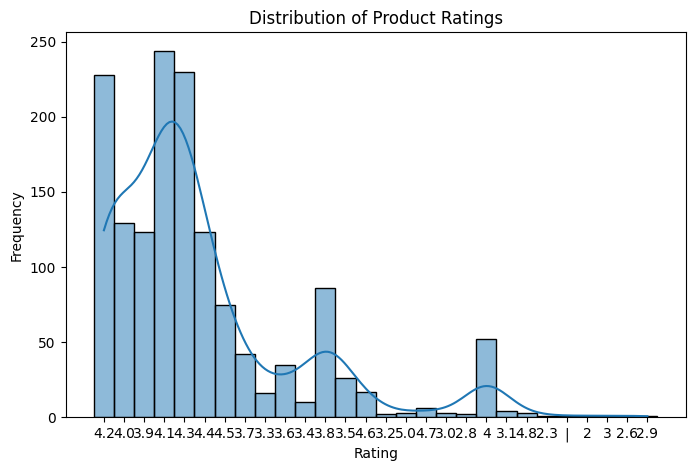

In [49]:
plt.figure(figsize=(8,5))
sns.histplot(df["rating"], bins=20, kde=True)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

# Top Product Categories

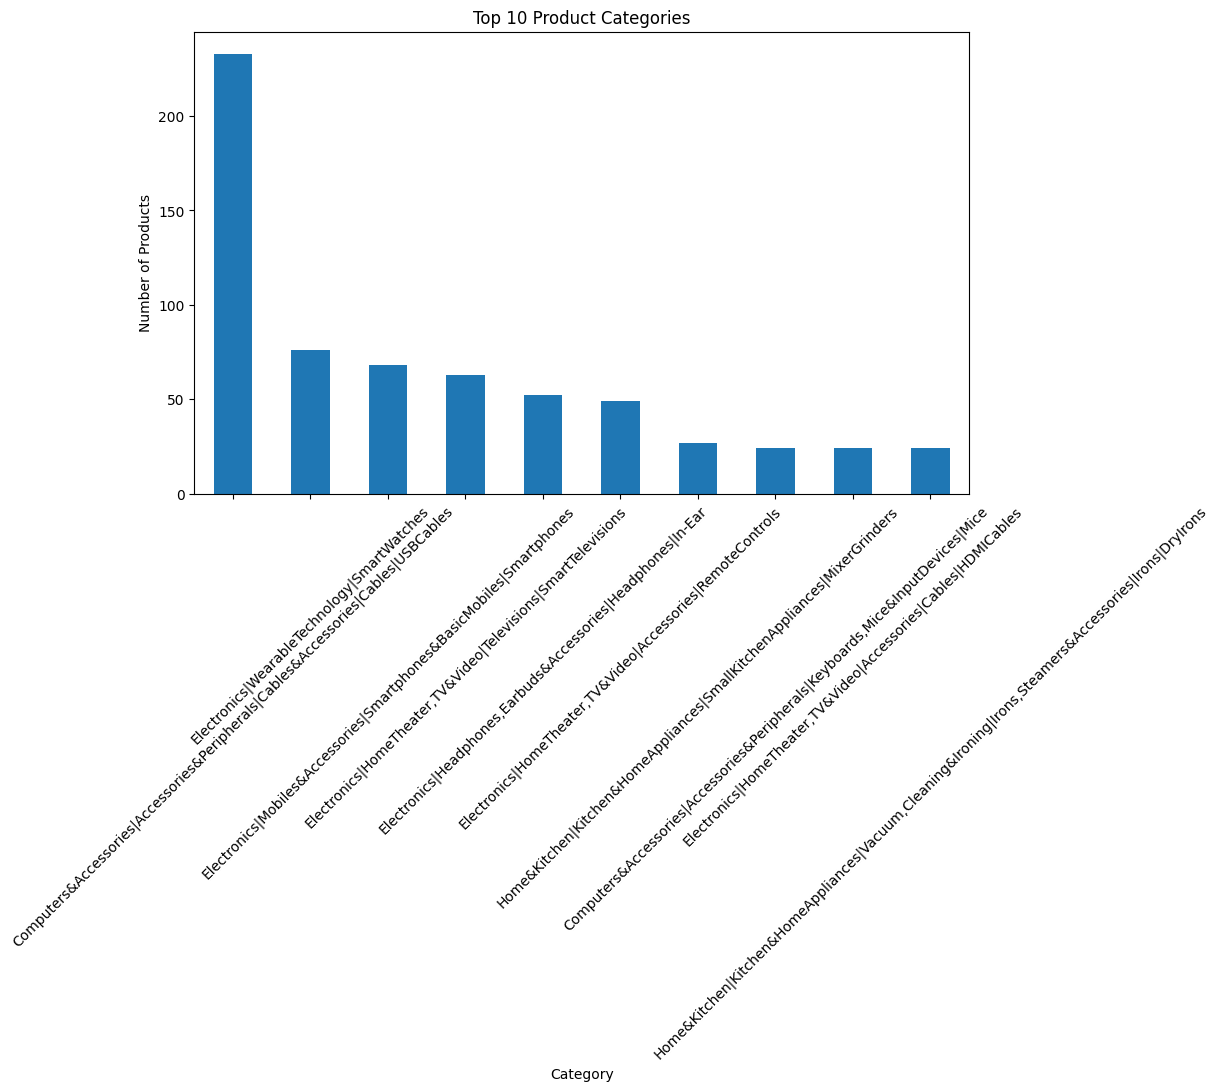

In [50]:
plt.figure(figsize=(10,6))
df["category"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

# Rating vs Rating Count

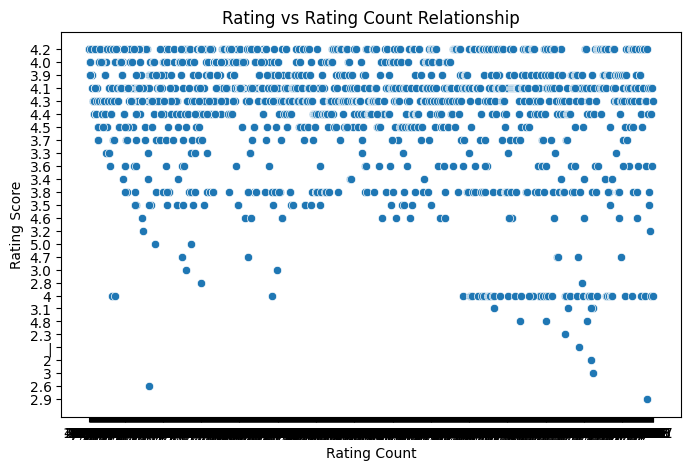

In [51]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["rating_count"],
    y=df["rating"]
)

plt.title("Rating vs Rating Count Relationship")
plt.xlabel("Rating Count")
plt.ylabel("Rating Score")
plt.show()

# Convert text into Document-Term Matrix

In [52]:
vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df["combined_features"])
tfidf_matrix.shape

(1465, 5000)

# Dimensionality reduction

In [53]:
svd = TruncatedSVD(n_components=100)
reduced_matrix = svd.fit_transform(tfidf_matrix)

# Similarity calculation (Cosine similarity)

In [54]:
similarity_matrix = cosine_similarity(reduced_matrix)

# Nearest Neighbour Model

In [55]:
model_knn = NearestNeighbors(metric="cosine", algorithm="brute")
model_knn.fit(reduced_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

# Build adjacency matrix (Graph input)

In [56]:
adjacency_matrix = cosine_similarity(reduced_matrix)

# Create graph using NetworkX

In [57]:
G = nx.from_numpy_array(adjacency_matrix)

# Community detection algorithm

In [58]:
communities = greedy_modularity_communities(G)

# PageRank algorithm

In [59]:
pagerank_scores = nx.pagerank(G)

# Attach PageRank scores to dataset

In [60]:
df["pagerank_score"] = df.index.map(pagerank_scores)
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,combined_features,pagerank_score
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,wayona nylon braided usb lightning fast chargi...,0.000708
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...,ambrane unbreakable w fast charging braided ty...,0.000779
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...,sounce fast phone charging cable data sync usb...,0.000721
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...,boat deuce usb type c micro usb stress resista...,0.000791
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...,portronics konnect l fast charging pin usb cab...,0.000824


# Recommendation function

In [61]:
def recommend_products(product_name, n=5):

    matches = df[df["product_name"].str.contains(
        product_name,
        case=False,
        na=False
    )]

    if matches.empty:
        print("Product not found. Showing popular recommendations instead.")
        return cold_start_recommendation(n)

    index = matches.index[0]

    distances, indices = model_knn.kneighbors(
        reduced_matrix[index].reshape(1, -1),
        n_neighbors=n + 1
    )

    recommendations = df.iloc[indices.flatten()[1:]]

    return recommendations[[
        "product_name",
        "category",
        "rating",
        "discount_percentage"
    ]]

In [62]:
recommend_products("Bluetooth Speaker")

,product_name,category,rating,discount_percentage
753,"Infinity (JBL Fuze Pint, Wireless Ultra Portab...",Electronics|HomeAudio|Speakers|OutdoorSpeakers,4.1,55%
1021,"Infinity (JBL Fuze 100, Wireless Portable Blue...",Electronics|HomeAudio|Speakers|OutdoorSpeakers,4.1,50%
883,"Infinity (JBL Glide 510, 72 Hrs Playtime with ...","Electronics|Headphones,Earbuds&Accessories|Hea...",4.2,63%
269,"KRISONS Thunder Speaker, Multimedia Home Theat...",Electronics|HomeAudio|Speakers|TowerSpeakers,3.8,43%
415,PTron Tangent Lite Bluetooth 5.0 Earphones wit...,"Electronics|Headphones,Earbuds&Accessories|Hea...",3.5,67%


# Hybrid ranking improvement (PageRank + similarity)

In [63]:
def hybrid_recommendation(product_name, n=5):

    matches = df[df["product_name"].str.contains(
            product_name,
            case=False,
            na=False
        )]

    index = matches.index[0]

    distances, indices = model_knn.kneighbors(
        reduced_matrix[index].reshape(1, -1),
        n_neighbors=20
    )

    candidate_products = df.iloc[indices.flatten()[1:]]

    ranked_products = candidate_products.sort_values(
        by="pagerank_score",
        ascending=False
    )

    return ranked_products.head(n)[[
        "product_name",
        "category",
        "rating",
        "pagerank_score"
    ]]

In [64]:
hybrid_recommendation("Bluetooth Speaker")

,product_name,category,rating,pagerank_score
415,PTron Tangent Lite Bluetooth 5.0 Earphones wit...,"Electronics|Headphones,Earbuds&Accessories|Hea...",3.5,0.000983
269,"KRISONS Thunder Speaker, Multimedia Home Theat...",Electronics|HomeAudio|Speakers|TowerSpeakers,3.8,0.000851
349,PTron Tangentbeat in-Ear Bluetooth 5.0 Wireles...,"Electronics|Headphones,Earbuds&Accessories|Hea...",3.9,0.000846
879,Sony WI-C100 Wireless Headphones with Customiz...,"Electronics|Headphones,Earbuds&Accessories|Hea...",3.6,0.000813
716,"JBL Tune 215BT, 16 Hrs Playtime with Quick Cha...","Electronics|Headphones,Earbuds&Accessories|Hea...",3.7,0.000805


# Cold-start fallback strategy

In [65]:
def cold_start_recommendation(n=5):

    return df.sort_values(
        by=["rating", "rating_count"],
        ascending=False
    ).head(n)[[
        "product_name",
        "category",
        "rating"
    ]]

# Model evaluation


In [66]:
top_similarities = similarity_matrix.mean(axis=1)

df["similarity_score"] = top_similarities

# Create product index lookup

In [67]:
product_indices = pd.Series(df.index, index=df["product_name"]).drop_duplicates()

# Improved recommendation function

In [68]:
def recommend_products(product_name, top_n=5):

    if product_name not in product_indices:
        print("Product not found. Showing popular recommendations instead.")
        return cold_start_recommendation(top_n)

    index = product_indices[product_name]

    similarity_scores = list(enumerate(similarity_matrix[index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n+1]

    product_indices_list = [i[0] for i in similarity_scores]

    recommendations = df.iloc[product_indices_list][[
        "product_name",
        "category",
        "rating",
        "discount_percentage"
    ]]

    return recommendations

# Hybrid recommendation

In [69]:
def hybrid_recommend_products(product_name, top_n=5):

    if product_name not in product_indices:
        print("Product not found. Showing popular recommendations instead.")
        return cold_start_recommendation(top_n)

    index = product_indices[product_name]

    similarity_scores = list(enumerate(similarity_matrix[index]))

    similarity_scores = similarity_scores[1:50]

    candidate_indices = [i[0] for i in similarity_scores]

    candidates = df.iloc[candidate_indices]

    ranked_candidates = candidates.sort_values(
        by=["pagerank_score", "rating"],
        ascending=False
    )

    return ranked_candidates.head(top_n)[[
        "product_name",
        "category",
        "rating",
        "pagerank_score",
        "discount_percentage"
    ]]

# Cold-start fallback recommender (new users / unknown product)

In [70]:
def cold_start_recommendation(top_n=5):

    popular_products = df.sort_values(
        by=["rating", "rating_count"],
        ascending=False
    )

    return popular_products.head(top_n)[[
        "product_name",
        "category",
        "rating",
        "rating_count",
        "discount_percentage"
    ]]

# Example usage

In [71]:
recommend_products("Boat Rockerz 450 Bluetooth Headphones")

Product not found. Showing popular recommendations instead.


,product_name,category,rating,rating_count,discount_percentage
1279,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",|,992,16%
174,Syncwire LTG to USB Cable for Fast Charging Co...,Computers&Accessories|Accessories&Peripherals|...,5.0,5,80%
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,Computers&Accessories|Accessories&Peripherals|...,5.0,23,50%
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories|Accessories&Peripherals|...,5.0,NaN,75%
1145,Swiffer Instant Electric Water Heater Faucet T...,"Home&Kitchen|Heating,Cooling&AirQuality|WaterH...",4.8,"53,803",28%


In [72]:
hybrid_recommend_products("Boat Rockerz 450 Bluetooth Headphones")

Product not found. Showing popular recommendations instead.


,product_name,category,rating,rating_count,discount_percentage
1279,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",|,992,16%
174,Syncwire LTG to USB Cable for Fast Charging Co...,Computers&Accessories|Accessories&Peripherals|...,5.0,5,80%
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,Computers&Accessories|Accessories&Peripherals|...,5.0,23,50%
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories|Accessories&Peripherals|...,5.0,NaN,75%
1145,Swiffer Instant Electric Water Heater Faucet T...,"Home&Kitchen|Heating,Cooling&AirQuality|WaterH...",4.8,"53,803",28%


In [73]:
cold_start_recommendation()

,product_name,category,rating,rating_count,discount_percentage
1279,Eureka Forbes car Vac 100 Watts Powerful Sucti...,"Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cle...",|,992,16%
174,Syncwire LTG to USB Cable for Fast Charging Co...,Computers&Accessories|Accessories&Peripherals|...,5.0,5,80%
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,Computers&Accessories|Accessories&Peripherals|...,5.0,23,50%
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories|Accessories&Peripherals|...,5.0,NaN,75%
1145,Swiffer Instant Electric Water Heater Faucet T...,"Home&Kitchen|Heating,Cooling&AirQuality|WaterH...",4.8,"53,803",28%
